## Post Processing

In [15]:
from pathlib import Path
from datetime import datetime
import re
import json
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "jupyter_notebooks" else Path.cwd()

# ============================================================================
# PATH & TIMESTAMP UTILITIES
# ============================================================================

def _as_project_path(path_like: str) -> Path:
    """Convert relative paths to project-root-relative paths."""
    p = Path(path_like)
    return p if p.is_absolute() else (PROJECT_ROOT / p)

def _ts_from_name(text: str):
    """Extract datetime (YYYYMMDD_HHMMSS) from filename."""
    m = re.search(r"(\d{8}_\d{6})", text)
    if not m:
        return None
    try:
        return datetime.strptime(m.group(1), "%Y%m%d_%H%M%S")
    except ValueError:
        return None

def _nearest_run_dir(parent: Path, ts: datetime):
    """Find the run directory on the same day with the nearest timestamp."""
    day_prefix = ts.strftime("%Y%m%d")
    run_dirs = sorted(parent.glob(f"cpmg_reopt_run_{day_prefix}_*"))
    if not run_dirs:
        return None

    best = None
    best_dt = None
    for run_dir in run_dirs:
        run_ts = _ts_from_name(run_dir.name)
        if run_ts is None:
            continue
        delta = abs((run_ts - ts).total_seconds())
        if best_dt is None or delta < best_dt:
            best = run_dir
            best_dt = delta
    return best

# ============================================================================
# HDF5 UTILITIES
# ============================================================================

def _collect_datasets(h5f: h5py.File):
    """Recursively collect all datasets from HDF5 file."""
    datasets = {}
    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            datasets[f"/{name}"] = np.asarray(obj[()])
    h5f.visititems(visitor)
    return datasets

def _find_series(datasets: dict, candidate_names):
    """Find first matching dataset by name."""
    for candidate in candidate_names:
        for key, value in datasets.items():
            if Path(key).name == candidate:
                return np.asarray(value)
    return None

def _resolve_chunk_files(path_like: str):
    """Return chunk h5 files for run folders, log files, or direct h5 paths."""
    p = _as_project_path(path_like)

    if p.is_dir():
        files = sorted(p.glob("*_chunk_*.h5"))
        if not files:
            files = sorted(p.glob("*chunk*.h5"))
        return files

    if p.is_file() and p.suffix.lower() == ".log":
        ts = _ts_from_name(p.stem)
        candidates = []
        if ts is not None:
            ts_str = ts.strftime("%Y%m%d_%H%M%S")
            candidates.append(p.parent / f"cpmg_reopt_run_{ts_str}")

        stem_candidate = p.stem.replace("terminal_", "")
        candidates.append(p.parent / stem_candidate)

        for candidate in candidates:
            if candidate.is_dir():
                files = sorted(candidate.glob("*_chunk_*.h5"))
                if files:
                    return files

        if ts is not None:
            nearest = _nearest_run_dir(p.parent, ts)
            if nearest is not None:
                files = sorted(nearest.glob("*_chunk_*.h5"))
                if files:
                    return files
        return []

    if p.is_file() and p.suffix.lower() in {".h5", ".hdf5"}:
        return [p]

    return []

# ============================================================================
# CORE LOADING: From Chunks or Combined Files
# ============================================================================

def load_run_data(run_path: str, verbose=True):
    """
    Load sweep data from a run (handles both combined h5 and chunk-based runs).
    
    Args:
        run_path: Path to run folder, combined h5, or log file
        verbose: Print status messages
    
    Returns:
        dict with keys:
            - tau_us: tau array in microseconds (sorted by chunk numerically)
            - data: list of dicts, each with keys:
                * chunk_id: simplified chunk number (0, 1, 2, ...)
                * signal: signal1 counts/s
                * reference: reference1 counts/s
                * contrast: signal/reference
                * source_file: original h5 filename
                * reps: repetition count for weighting
            - run_name: name of the run
            - mode: "combined" or "chunks"
    """
    run_path = _as_project_path(run_path)
    
    # Try combined h5 first if path is directory
    combined_h5 = None
    if run_path.is_dir():
        candidates = sorted(run_path.glob("*combined*.h5"))
        if candidates:
            combined_h5 = candidates[0]
    elif run_path.is_file() and run_path.suffix.lower() in {".h5", ".hdf5"}:
        combined_h5 = run_path
    
    # Load from combined file
    if combined_h5 is not None and combined_h5.exists():
        try:
            return _load_from_combined(combined_h5, verbose=verbose)
        except Exception as e:
            if verbose:
                print(f"  Combined file load failed ({e}), trying chunks...")
    
    # Fall back to chunks
    run_folder = run_path if run_path.is_dir() else run_path.parent
    return _load_from_chunks(run_folder, verbose=verbose)


def _load_from_combined(h5_path: Path, verbose=True):
    """Load from a single combined HDF5 file."""
    h5_path = Path(h5_path)
    
    with h5py.File(h5_path, "r") as h5f:
        datasets = _collect_datasets(h5f)
        
        tau = _find_series(datasets, ["tau_ns", "tau_ftns", "tau_tus", "tau_samples"])
        signal = _find_series(datasets, ["signal1_cts_s", "signal1"])
        reference = _find_series(datasets, ["reference1_cts_s", "reference1"])
    
    if tau is None or signal is None or reference is None:
        raise KeyError("Missing tau or signal/reference in combined file")
    
    tau = np.asarray(tau, dtype=float).ravel()
    if tau.min() < 100:
        tau_us = tau * 0.20345052083333334 / 1e3
    else:
        tau_us = tau / 1e3
    
    signal = np.asarray(signal, dtype=float).ravel()
    reference = np.asarray(reference, dtype=float).ravel()
    
    # Single "chunk" representing the entire combined file
    data = [{
        "chunk_id": 0,
        "signal": signal,
        "reference": reference,
        "contrast": signal / np.clip(reference, 1e-12, None),
        "source_file": h5_path.name,
        "reps": 1.0,
    }]
    
    if verbose:
        print(f"✓ Loaded from combined: {h5_path.name}")
    
    return {
        "tau_us": tau_us,
        "data": data,
        "run_name": h5_path.parent.name,
        "mode": "combined",
    }


def _load_from_chunks(run_folder: Path, verbose=True):
    """Load from chunk files in a run folder."""
    run_folder = Path(run_folder)
    chunk_files = _resolve_chunk_files(str(run_folder))
    
    if not chunk_files:
        raise FileNotFoundError(f"No chunk files found in {run_folder}")
    
    tau_ref = None
    data_list = []
    
    for chunk_idx, chunk_file in enumerate(chunk_files):
        try:
            with h5py.File(chunk_file, "r") as h5f:
                datasets = _collect_datasets(h5f)
                
                tau = _find_series(datasets, ["tau_ns", "tau_ftns", "tau_tus", "tau_samples"])
                signal = _find_series(datasets, ["signal1_cts_s", "signal1"])
                reference = _find_series(datasets, ["reference1_cts_s", "reference1"])
                
                if tau is None or signal is None or reference is None:
                    if verbose:
                        print(f"  ⚠ Skipping {chunk_file.name} (missing datasets)")
                    continue
                
                tau = np.asarray(tau, dtype=float).ravel()
                signal = np.asarray(signal, dtype=float).ravel()
                reference = np.asarray(reference, dtype=float).ravel()
                
                # Establish tau reference from first chunk
                if tau_ref is None:
                    if tau.min() < 100:
                        tau_us = tau * 0.20345052083333334 / 1e3
                    else:
                        tau_us = tau / 1e3
                    tau_ref = tau_us
                
                # Get reps
                reps = 1.0
                if "experiment" in h5f and hasattr(h5f["experiment"], "attrs"):
                    try:
                        reps = float(h5f["experiment"].attrs.get("reps", 1.0))
                    except (TypeError, ValueError):
                        reps = 1.0
                
                contrast = signal / np.clip(reference, 1e-12, None)
                
                data_list.append({
                    "chunk_id": chunk_idx,
                    "signal": signal,
                    "reference": reference,
                    "contrast": contrast,
                    "source_file": chunk_file.name,
                    "reps": reps,
                })
        
        except Exception as e:
            if verbose:
                print(f"  ⚠ Error loading {chunk_file.name}: {e}")
            continue
    
    if not data_list or tau_ref is None:
        raise RuntimeError(f"Could not load any valid chunks from {run_folder}")
    
    if verbose:
        print(f"✓ Loaded {len(data_list)} chunks from {run_folder.name}")
    
    return {
        "tau_us": tau_ref,
        "data": data_list,
        "run_name": run_folder.name,
        "mode": "chunks",
    }

# ============================================================================
# DATA INSPECTION & FILTERING
# ============================================================================

def summarize_chunks(run_data):
    """
    Print summary of chunk statistics.
    
    Args:
        run_data: dict from load_run_data()
    
    Returns:
        DataFrame with chunk statistics
    """
    rows = []
    for chunk in run_data["data"]:
        rows.append({
            "chunk_id": chunk["chunk_id"],
            "source_file": chunk["source_file"],
            "signal_mean": np.mean(chunk["signal"]),
            "signal_std": np.std(chunk["signal"], ddof=1) if len(chunk["signal"]) > 1 else 0.0,
            "reference_mean": np.mean(chunk["reference"]),
            "reference_std": np.std(chunk["reference"], ddof=1) if len(chunk["reference"]) > 1 else 0.0,
            "contrast_mean": np.mean(chunk["contrast"]),
            "reps": chunk["reps"],
        })
    
    df = pd.DataFrame(rows)
    print(f"\n{run_data['run_name']} ({run_data['mode']} mode) — {len(df)} chunk(s):")
    print(df.to_string(index=False))
    return df


def filter_chunks(run_data, chunk_ids=None, reference_min=None, reference_max=None):
    """
    Filter run data to include only selected chunks.
    
    Args:
        run_data: dict from load_run_data()
        chunk_ids: list of chunk_id values to keep (e.g., [0, 1, 2])
        reference_min: exclude chunks with reference_mean < this value
        reference_max: exclude chunks with reference_mean > this value
    
    Returns:
        Filtered run_data dict (same structure)
    """
    filtered_data = []
    
    for chunk in run_data["data"]:
        # Check chunk_id filter
        if chunk_ids is not None and chunk["chunk_id"] not in chunk_ids:
            continue
        
        # Check reference bounds
        ref_mean = np.mean(chunk["reference"])
        if reference_min is not None and ref_mean < reference_min:
            continue
        if reference_max is not None and ref_mean > reference_max:
            continue
        
        filtered_data.append(chunk)
    
    return {
        "tau_us": run_data["tau_us"],
        "data": filtered_data,
        "run_name": run_data["run_name"],
        "mode": run_data["mode"],
    }

# ============================================================================
# PLOTTING
# ============================================================================

def _aggregate_chunks(run_data):
    """
    Aggregate all chunks in run_data by summing with reps weighting.
    
    Args:
        run_data: dict from load_run_data()
    
    Returns:
        Tuple of (signal_agg, reference_agg, contrast_agg) arrays
    """
    if not run_data["data"]:
        raise ValueError("No chunks to aggregate")
    
    tau_len = len(run_data["tau_us"])
    signal_acc = np.zeros(tau_len, dtype=float)
    reference_acc = np.zeros(tau_len, dtype=float)
    weight_total = 0.0
    
    for chunk in run_data["data"]:
        reps = chunk.get("reps", 1.0)
        signal_acc += reps * chunk["signal"]
        reference_acc += reps * chunk["reference"]
        weight_total += reps
    
    # Average by total weight
    if weight_total > 0:
        signal_agg = signal_acc / weight_total
        reference_agg = reference_acc / weight_total
    else:
        signal_agg = signal_acc
        reference_agg = reference_acc
    
    contrast_agg = signal_agg / np.clip(reference_agg, 1e-12, None)
    
    return signal_agg, reference_agg, contrast_agg


def plot_sweep(run_data, title_suffix=""):
    """
    Plot aggregated sweep data (tau vs signal/reference) in microseconds.
    
    Aggregates all chunks using reps weighting before plotting.
    
    Args:
        run_data: dict from load_run_data() (optionally filtered)
        title_suffix: additional text for title
    """
    tau_us = run_data["tau_us"]
    signal_agg, reference_agg, contrast_agg = _aggregate_chunks(run_data)
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Plot 1: Aggregated Signal and Reference
    axes[0].plot(
        tau_us,
        signal_agg,
        "o-",
        lw=1.3,
        ms=4,
        alpha=0.85,
        color="#1f77b4",
        label="signal (aggregated)",
    )
    axes[0].plot(
        tau_us,
        reference_agg,
        "s-",
        lw=1.3,
        ms=3.5,
        alpha=0.85,
        color="#d62728",
        label="reference (aggregated)",
    )
    
    axes[0].set_ylabel("counts/s")
    axes[0].set_title(f"Signal & Reference {title_suffix}")
    axes[0].grid(alpha=0.3)
    axes[0].legend(fontsize=10, loc="best")
    
    # Plot 2: Aggregated Contrast
    axes[1].plot(
        tau_us,
        contrast_agg,
        "o-",
        lw=1.3,
        ms=4,
        alpha=0.85,
        color="#2b8cbe",
        label="contrast (aggregated)",
    )
    
    axes[1].set_xlabel("τ (µs)")
    axes[1].set_ylabel("signal / reference")
    axes[1].set_title(f"Contrast {title_suffix}")
    axes[1].grid(alpha=0.3)
    axes[1].legend(fontsize=10, loc="best")
    
    plt.tight_layout()
    plt.show()


In [16]:
%matplotlib widget


In [17]:
# Quick Start: Load & Plot a Run

# Edit the `run_path` below to point to any run folder, combined h5 file, or reopt log file.


In [18]:
# ============================================================================
# STEP 1: Load Run (combined or chunks)
# ============================================================================

# Edit this to point to your run:
run_path = r"data\cpmg_reopt\cpmg_reopt_run_20260331_182347"

# Load the run
run_data = load_run_data(run_path, verbose=True)
print(f"\nRun mode: {run_data['mode']}")
print(f"Tau range: {run_data['tau_us'].min():.3f} – {run_data['tau_us'].max():.3f} µs")
print(f"Num chunks: {len(run_data['data'])}")


  Combined file load failed ('Missing tau or signal/reference in combined file'), trying chunks...
✓ Loaded 50 chunks from cpmg_reopt_run_20260331_182347

Run mode: chunks
Tau range: 0.200 – 9.152 µs
Num chunks: 50


In [19]:
# ============================================================================
# STEP 2: Inspect & Filter Chunks
# ============================================================================

# Print statistics for all chunks
chunk_stats = summarize_chunks(run_data)

# Optional: Filter chunks by various criteria
# Examples:
#   - Keep only chunks 0, 1, 2:
#     filtered = filter_chunks(run_data, chunk_ids=[0, 1, 2])
#
#   - Exclude chunks with low reference counts (< 500):
#     filtered = filter_chunks(run_data, reference_min=500)
#
#   - Exclude chunks with high reference counts (> 1000):
#     filtered = filter_chunks(run_data, reference_max=1000)

# For now, use all chunks
filtered_run = run_data
print(f"\nUsing {len(filtered_run['data'])} chunks")



cpmg_reopt_run_20260331_182347 (chunks mode) — 50 chunk(s):
 chunk_id                               source_file  signal_mean  signal_std  reference_mean  reference_std  contrast_mean   reps
        0 cpmg_xy_fine_res_chunk_20260331_184159.h5  9491.798746 2778.303284    10067.654325    2861.632135       1.032841 2000.0
        1 cpmg_xy_fine_res_chunk_20260331_190047.h5 69536.045381 8274.840959    75775.926933    7906.328536       0.927775 2000.0
        2 cpmg_xy_fine_res_chunk_20260331_191935.h5 68180.204608 8187.083203    74016.393589    7925.564253       0.931602 2000.0
        3 cpmg_xy_fine_res_chunk_20260331_193822.h5 69489.465469 8472.039940    75612.440575    7891.522524       0.929209 2000.0
        4 cpmg_xy_fine_res_chunk_20260331_195710.h5 68647.830391 8336.221517    75276.791209    8128.655125       0.922349 2000.0
        5 cpmg_xy_fine_res_chunk_20260331_201558.h5 67707.098834 8026.708699    74021.416913    7734.424229       0.924739 2000.0
        6 cpmg_xy_fine_res_ch

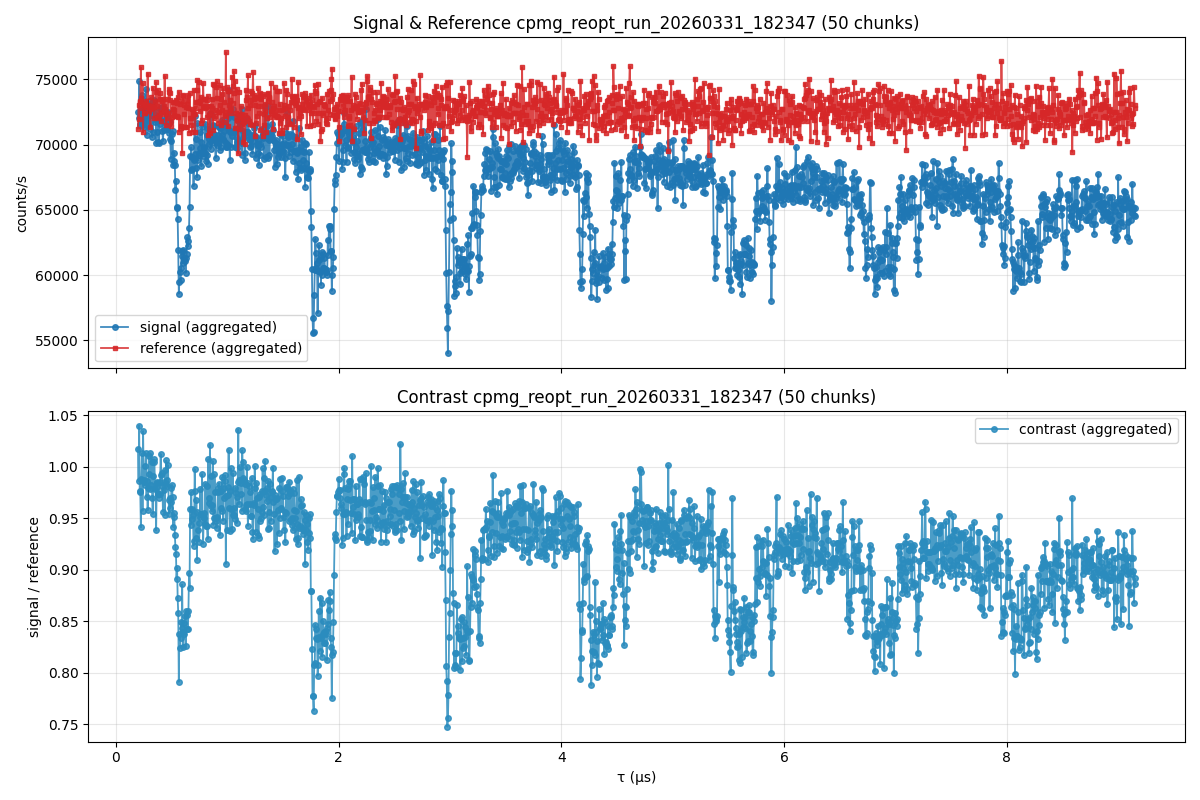

In [20]:
# ============================================================================
# STEP 3: Plot Sweep Data
# ============================================================================

# Plot with a title showing the run name and filtering applied
title = f"{filtered_run['run_name']}"
if filtered_run['mode'] == 'chunks':
    title += f" ({len(filtered_run['data'])} chunks)"

plot_sweep(filtered_run, title_suffix=title)


# Advanced: Filtering & Comparison


In [21]:
# Optional: Filter chunks by reference level (e.g., exclude noisy chunks)
# 
# Uncomment and edit one of the examples below:

# Example 1: Keep only chunks 0 and 1
# filtered_run = filter_chunks(run_data, chunk_ids=[0, 1])

# Example 2: Exclude chunks with low reference counts (< 500 counts/s)
# filtered_run = filter_chunks(run_data, reference_min=500)

# Example 3: Exclude chunks with high reference counts (> 1500 counts/s)
# filtered_run = filter_chunks(run_data, reference_max=1500)

# Example 4: Combine multiple filters
# filtered_run = filter_chunks(run_data, chunk_ids=[0, 1, 2, 3], reference_min=450)

# After filtering, replot:
# plot_sweep(filtered_run, title_suffix=f"{filtered_run['run_name']} (filtered)")


# Compare Multiple Runs


In [22]:
# Load and compare multiple runs
# Edit the run paths below:

runs_to_compare = {
    "run_A": r"data\cpmg_reopt\cpmg_reopt_run_20260324_222413",
    "run_B": r"data\cpmg_reopt\cpmg_reopt_run_20260326_224519",
    # "run_C": r"data\cpmg_reopt\cpmg_reopt_run_20260327_191002",
}

# Load all runs
comparison_data = {}
for label, path in runs_to_compare.items():
    try:
        comparison_data[label] = load_run_data(path, verbose=True)
    except Exception as e:
        print(f"✗ Failed to load {label}: {e}")

# Plot comparison (aggregated)
if comparison_data:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(comparison_data)))
    
    for (label, data), color in zip(comparison_data.items(), colors):
        tau_us = data["tau_us"]
        # Aggregate chunks
        signal_agg, reference_agg, contrast_agg = _aggregate_chunks(data)
        
        ax.plot(
            tau_us,
            contrast_agg,
            "o-",
            lw=1.5,
            ms=4,
            label=label,
            color=color,
            alpha=0.8,
        )
    
    ax.set_xlabel("τ (µs)")
    ax.set_ylabel("signal / reference")
    ax.set_title("Contrast Comparison (aggregated)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()


✗ Failed to load run_A: No chunk files found in c:\Users\vsmar\Documents\Research\qick-dawg\data\cpmg_reopt
✗ Failed to load run_B: No chunk files found in c:\Users\vsmar\Documents\Research\qick-dawg\data\cpmg_reopt


# Export Data


In [23]:
# Export filtered data to CSV
# Using the filtered_run from above

def export_to_csv(run_data, filename=None):
    """
    Export sweep data to CSV (tau_us, and per-chunk signal/reference/contrast).
    
    Args:
        run_data: dict from load_run_data()
        filename: output CSV filename (default: {run_name}_sweep.csv)
    """
    if filename is None:
        filename = f"{run_data['run_name']}_sweep.csv"
    
    tau_us = run_data["tau_us"]
    rows = []
    
    for chunk in run_data["data"]:
        for i, tau in enumerate(tau_us):
            rows.append({
                "tau_us": tau,
                "chunk_id": chunk["chunk_id"],
                "signal": chunk["signal"][i],
                "reference": chunk["reference"][i],
                "contrast": chunk["contrast"][i],
            })
    
    df = pd.DataFrame(rows)
    df.to_csv(filename, index=False)
    print(f"✓ Exported {len(df)} rows to {filename}")
    return df

# Example usage:
# df = export_to_csv(filtered_run)


In [24]:
C = 0.8414
A = 0.1547

In [25]:
def plot_sweep_0pop(run_data, title_suffix=""):
    """
    Plot aggregated sweep data (tau vs signal/reference) in microseconds.
    
    Aggregates all chunks using reps weighting before plotting.
    
    Args:
        run_data: dict from load_run_data() (optionally filtered)
        title_suffix: additional text for title
    """
    tau_us = run_data["tau_us"]
    signal_agg, reference_agg, contrast_agg = _aggregate_chunks(run_data)

    contrast_0pop = (contrast_agg - 0.8414) / (0.1547*2) + 0.5
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Plot 1: Aggregated Signal and Reference
    axes[0].plot(
        tau_us,
        signal_agg,
        "o-",
        lw=1.3,
        ms=4,
        alpha=0.85,
        color="#1f77b4",
        label="signal (aggregated)",
    )
    axes[0].plot(
        tau_us,
        reference_agg,
        "s-",
        lw=1.3,
        ms=3.5,
        alpha=0.85,
        color="#d62728",
        label="reference (aggregated)",
    )
    
    axes[0].set_ylabel("counts/s")
    axes[0].set_title(f"Signal & Reference {title_suffix}")
    axes[0].grid(alpha=0.3)
    axes[0].legend(fontsize=10, loc="best")
    
    # Plot 2: Aggregated Contrast
    axes[1].plot(
        tau_us,
        contrast_0pop,
        "o-",
        lw=1.3,
        ms=4,
        alpha=0.85,
        color="#2b8cbe",
        label="contrast (aggregated)",
    )
    
    axes[1].set_xlabel("τ (µs)")
    axes[1].set_ylabel("signal / reference")
    axes[1].set_title(f"Contrast {title_suffix}")
    axes[1].grid(alpha=0.3)
    axes[1].legend(fontsize=10, loc="best")
    
    plt.tight_layout()
    plt.show()


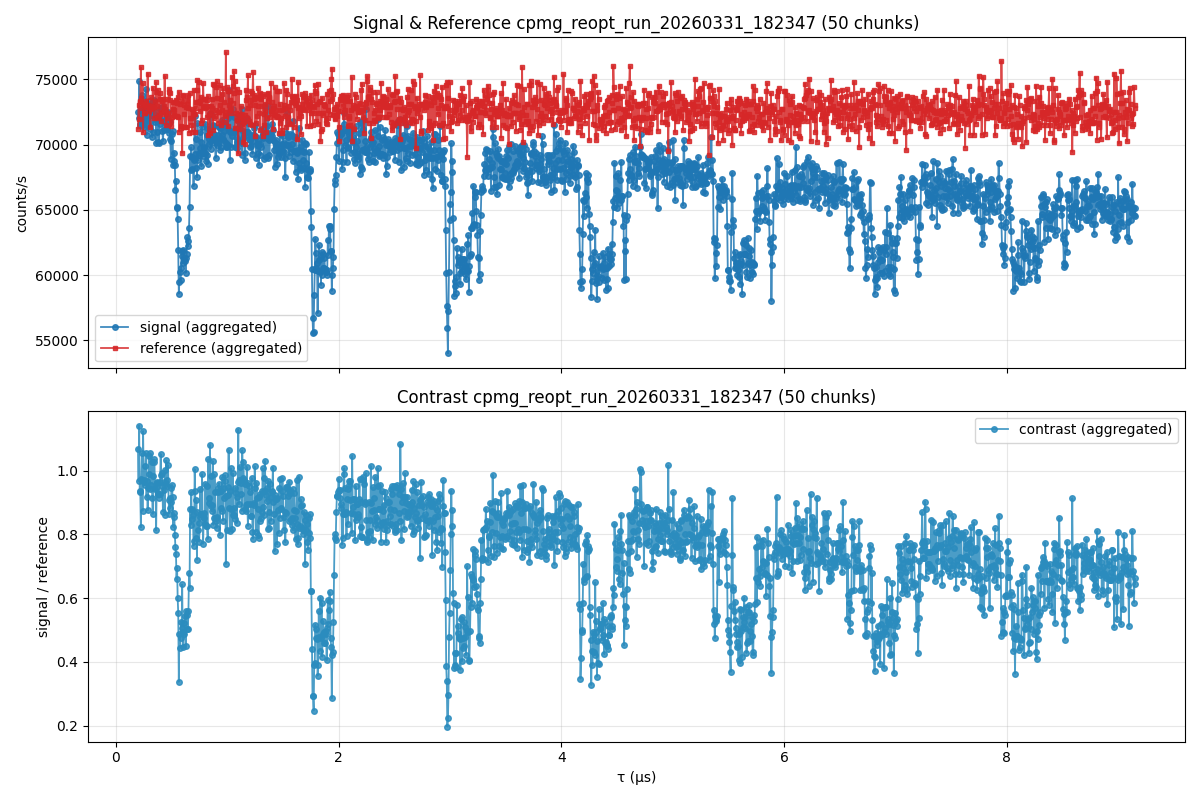

In [26]:
title = f"{filtered_run['run_name']}"
if filtered_run['mode'] == 'chunks':
    title += f" ({len(filtered_run['data'])} chunks)"

plot_sweep_0pop(filtered_run, title_suffix=title)


[t1] Difference fit: A=-19429.8, T1=1588.097 us, C=-2476.34


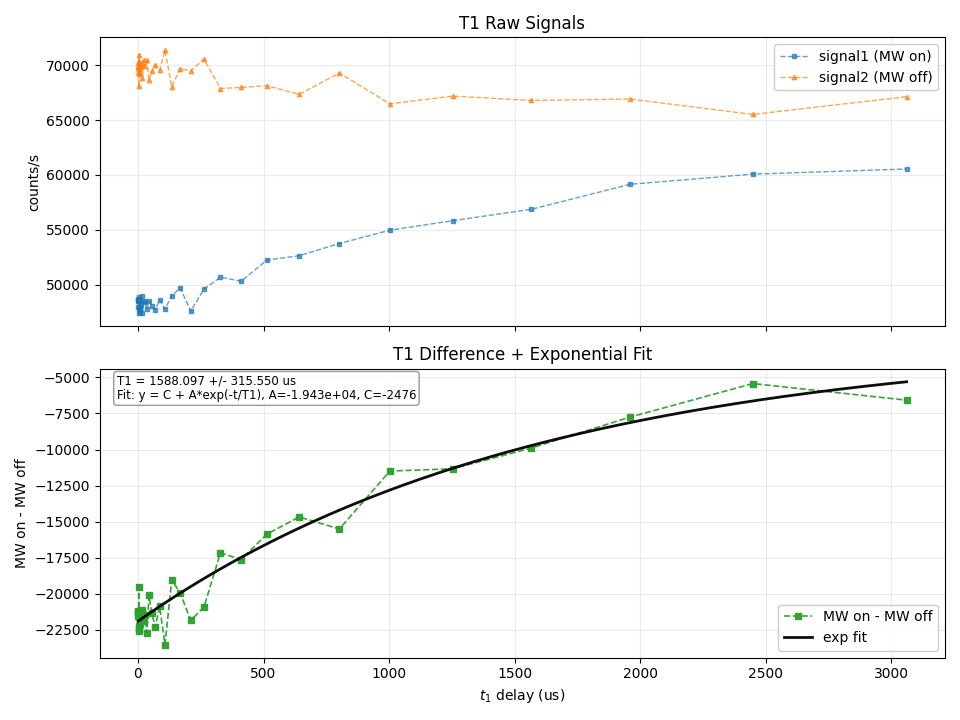

In [28]:
from pathlib import Path
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "jupyter_notebooks" else Path.cwd()

def _collect_datasets_local(h5f):
    datasets = {}
    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            datasets[f"/{name}"] = np.asarray(obj[()])
    h5f.visititems(visitor)
    return datasets

t1_file = Path(r"data\t1\t1_fine_res_combined.h5")
if not t1_file.is_absolute():
    t1_file = PROJECT_ROOT / t1_file

with h5py.File(t1_file, "r") as h5f:
    t1_datasets = _collect_datasets_local(h5f)

signal1_cts_s = np.asarray(t1_datasets["/data/signal1_cts_s"], dtype=float).ravel()
signal2_cts_s = np.asarray(t1_datasets["/data/signal2_cts_s"], dtype=float).ravel()
tau_ns = np.asarray(t1_datasets["/data/t1_delay_tns"], dtype=float).ravel()

diff_signal = signal1_cts_s - signal2_cts_s
x_us = tau_ns / 1e3

n = min(len(x_us), len(signal1_cts_s), len(signal2_cts_s), len(diff_signal))
x_us = x_us[:n]
signal1_cts_s = signal1_cts_s[:n]
signal2_cts_s = signal2_cts_s[:n]
diff_signal = diff_signal[:n]

def _exp_decay(x_us_arr, amplitude, t1_us, offset):
    x_us_arr = np.asarray(x_us_arr, dtype=float)
    safe_t1 = np.clip(float(t1_us), 1e-9, None)
    return offset + amplitude * np.exp(-np.clip(x_us_arr, 0.0, None) / safe_t1)

def _fit_t1_difference(x_us_arr, y):
    x_us_arr = np.asarray(x_us_arr, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)
    finite = np.isfinite(x_us_arr) & np.isfinite(y)
    x_us_arr = x_us_arr[finite]
    y = y[finite]
    if len(x_us_arr) < 5:
        return None
    order = np.argsort(x_us_arr)
    x_us_arr = x_us_arr[order]
    y = y[order]
    span = float(np.max(x_us_arr) - np.min(x_us_arr))
    if span <= 0:
        return None
    y_lo, y_hi = float(np.min(y)), float(np.max(y))
    y_range = max(y_hi - y_lo, float(np.std(y)) * 2.0, 1e-6)
    p0 = [float(y[0] - y[-1]), max(span / 2.0, 1e-3), float(y[-1])]
    bounds = ([-5.0 * y_range, max(span / 500.0, 1e-3), y_lo - y_range], [5.0 * y_range, max(span * 20.0, 10.0), y_hi + y_range])
    try:
        params, cov = curve_fit(_exp_decay, x_us_arr, y, p0=p0, bounds=bounds, maxfev=60000)
        fit_x = np.linspace(float(np.min(x_us_arr)), float(np.max(x_us_arr)), max(500, len(x_us_arr) * 20))
        fit_sigma = np.sqrt(np.diag(cov)) if cov is not None else np.full(len(params), np.nan)
        return {"params": params, "fit_x": fit_x, "fit_y": _exp_decay(fit_x, *params), "t1_us": float(params[1]), "t1_sigma_us": float(fit_sigma[1]) if len(fit_sigma) > 1 else np.nan}
    except (RuntimeError, ValueError):
        return None

fit = _fit_t1_difference(x_us, diff_signal)

plt.close("all")
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(9.6, 7.2), sharex=True)
ax_top.plot(x_us, signal1_cts_s, "s--", lw=1.0, ms=3.2, alpha=0.7, color="tab:blue", label="signal1 (MW on)")
ax_top.plot(x_us, signal2_cts_s, "^--", lw=1.0, ms=3.2, alpha=0.7, color="tab:orange", label="signal2 (MW off)")
ax_top.set_ylabel("counts/s")
ax_top.set_title("T1 Raw Signals")
ax_top.grid(alpha=0.25)
ax_top.legend(loc="best", framealpha=0.95)
ax_bottom.plot(x_us, diff_signal, "s--", markersize=4.2, linewidth=1.2, alpha=0.95, color="tab:green", label="MW on - MW off")

if fit is not None:
    t1_us = float(fit["t1_us"])
    t1_sigma_us = float(fit["t1_sigma_us"])
    amp = float(fit["params"][0])
    offset = float(fit["params"][2])
    ax_bottom.plot(fit["fit_x"], fit["fit_y"], "-", linewidth=2.0, color="black", alpha=0.95, label="exp fit")
    print(f"[t1] Difference fit: A={amp:.6g}, T1={t1_us:.3f} us, C={offset:.6g}")
    fit_text = f"T1 = {t1_us:.3f} +/- {t1_sigma_us:.3f} us" if np.isfinite(t1_sigma_us) else f"T1 = {t1_us:.3f} us"
    fit_model_text = f"Fit: y = C + A*exp(-t/T1), A={amp:.4g}, C={offset:.4g}"
else:
    fit_text = "T1: fit did not converge"
    fit_model_text = "Fit: did not converge."
    print("[t1] Difference fit skipped: fit did not converge.")

ax_bottom.set_xlabel(r"$t_1$ delay (us)")
ax_bottom.set_ylabel("MW on - MW off")
ax_bottom.set_title("T1 Difference + Exponential Fit")
ax_bottom.grid(alpha=0.25)
ax_bottom.legend(loc="best", framealpha=0.95)
ax_bottom.text(0.02, 0.98, f"{fit_text}\n{fit_model_text}", transform=ax_bottom.transAxes, ha="left", va="top", fontsize=8.5, bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, edgecolor="gray"))
plt.tight_layout()
plt.show()

[hahn_echo] T2 fit: A=0.20438, T2=677.730 us, C=0.778552


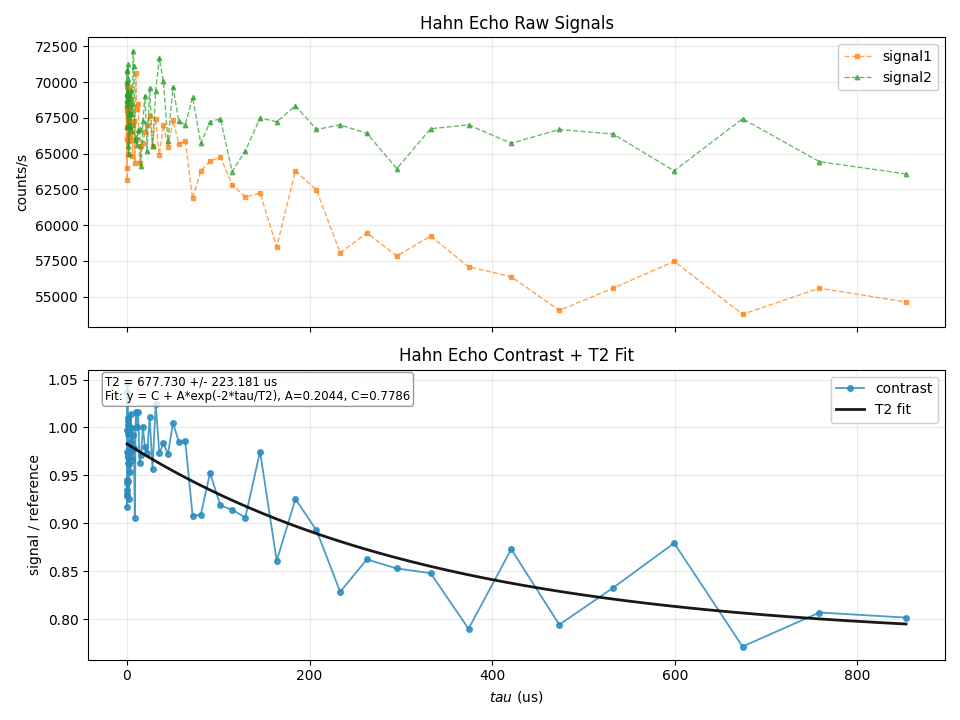

: 

In [ ]:
from pathlib import Path
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "jupyter_notebooks" else Path.cwd()

def _collect_datasets_local(h5f):
    datasets = {}
    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            datasets[f"/{name}"] = np.asarray(obj[()])
    h5f.visititems(visitor)
    return datasets

def _find_series_local(datasets, candidate_names):
    for candidate in candidate_names:
        for key, value in datasets.items():
            if Path(key).name == candidate:
                return np.asarray(value)
    return None

hahn_file = Path(r"data\hahn_echo\hahn_echo_fine_res_combined.h5")
if not hahn_file.is_absolute():
    hahn_file = PROJECT_ROOT / hahn_file

with h5py.File(hahn_file, "r") as h5f:
    hahn_datasets = _collect_datasets_local(h5f)

tau_us = _find_series_local(hahn_datasets, ["tau_ftus", "tau_tus", "tau_us", "tau_ftns", "tau_ns"])
signal1 = _find_series_local(hahn_datasets, ["signal1_cts_s", "signal1"])
signal2 = _find_series_local(hahn_datasets, ["signal2_cts_s", "signal2"])
reference1 = _find_series_local(hahn_datasets, ["reference1_cts_s", "reference1"])
reference2 = _find_series_local(hahn_datasets, ["reference2_cts_s", "reference2"])

if tau_us is None or signal1 is None or signal2 is None:
    raise KeyError("Missing required Hahn datasets")

tau_us = np.asarray(tau_us, dtype=float).ravel()
signal1 = np.asarray(signal1, dtype=float).ravel()
signal2 = np.asarray(signal2, dtype=float).ravel()
if np.nanmax(tau_us) > 1e4:
    tau_us = tau_us / 1e3

if reference1 is not None:
    reference1 = np.asarray(reference1, dtype=float).ravel()
    contrast = signal1 / np.clip(reference1, 1e-12, None)
elif reference2 is not None:
    reference2 = np.asarray(reference2, dtype=float).ravel()
    contrast = signal2 / np.clip(reference2, 1e-12, None)
else:
    contrast = signal1 / np.clip(signal2, 1e-12, None)

n = min(len(tau_us), len(signal1), len(signal2), len(contrast))
tau_us = tau_us[:n]
signal1 = signal1[:n]
signal2 = signal2[:n]
contrast = contrast[:n]

def _exp_decay_t2(tau_us_arr, amplitude, t2_us, offset):
    tau_us_arr = np.asarray(tau_us_arr, dtype=float)
    safe_t2 = np.clip(float(t2_us), 1e-9, None)
    return offset + amplitude * np.exp(-2.0 * np.clip(tau_us_arr, 0.0, None) / safe_t2)

def _fit_t2_contrast(x_axis, contrast_data):
    x_us = np.asarray(x_axis, dtype=float).reshape(-1)
    y = np.asarray(contrast_data, dtype=float).reshape(-1)
    finite = np.isfinite(x_us) & np.isfinite(y)
    x_us = x_us[finite]
    y = y[finite]
    if len(x_us) < 5:
        return None
    order = np.argsort(x_us)
    x_us = x_us[order]
    y = y[order]
    span = float(np.max(x_us) - np.min(x_us))
    if span <= 0:
        return None
    y_lo, y_hi = float(np.min(y)), float(np.max(y))
    y_range = max(y_hi - y_lo, float(np.std(y)) * 2.0, 1e-6)
    p0 = [float(y[0] - y[-1]), max(span / 2.0, 1e-3), float(y[-1])]
    bounds = ([-5.0 * y_range, max(span / 500.0, 1e-3), y_lo - y_range], [5.0 * y_range, max(span * 20.0, 10.0), y_hi + y_range])
    try:
        params, cov = curve_fit(_exp_decay_t2, x_us, y, p0=p0, bounds=bounds, maxfev=60000)
        fit_x = np.linspace(float(np.min(x_us)), float(np.max(x_us)), max(500, len(x_us) * 20))
        fit_sigma = np.sqrt(np.diag(cov)) if cov is not None else np.full(len(params), np.nan)
        return {"params": params, "fit_x": fit_x, "fit_y": _exp_decay_t2(fit_x, *params), "t2_us": float(params[1]), "t2_sigma_us": float(fit_sigma[1]) if len(fit_sigma) > 1 else np.nan}
    except (RuntimeError, ValueError):
        return None

t2_fit = _fit_t2_contrast(tau_us, contrast)

plt.close("all")
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(9.6, 7.2), sharex=True)
ax_top.plot(tau_us, signal1, "s--", lw=1.0, ms=3.2, alpha=0.7, color="tab:orange", label="signal1")
ax_top.plot(tau_us, signal2, "^--", lw=1.0, ms=3.2, alpha=0.7, color="tab:green", label="signal2")
ax_top.set_ylabel("counts/s")
ax_top.set_title("Hahn Echo Raw Signals")
ax_top.grid(alpha=0.25)
ax_top.legend(loc="best", framealpha=0.95)
ax_bottom.plot(tau_us, contrast, "o-", lw=1.3, ms=4, alpha=0.85, color="#2b8cbe", label="contrast")

if t2_fit is not None:
    ax_bottom.plot(t2_fit["fit_x"], t2_fit["fit_y"], "-", linewidth=2.0, color="black", alpha=0.9, label="T2 fit")
    t2_us = float(t2_fit["t2_us"])

    t2_sigma_us = float(t2_fit["t2_sigma_us"])

    amp = float(t2_fit["params"][0])
    offset = float(t2_fit["params"][2])
    print(f"[hahn_echo] T2 fit: A={amp:.6g}, T2={t2_us:.3f} us, C={offset:.6g}")
    t2_text = f"T2 = {t2_us:.3f} +/- {t2_sigma_us:.3f} us" if np.isfinite(t2_sigma_us) else f"T2 = {t2_us:.3f} us"
    fit_text = f"Fit: y = C + A*exp(-2*tau/T2), A={amp:.4g}, C={offset:.4g}"
else:
    print("[hahn_echo] T2 fit skipped: fit did not converge.")
    t2_text = "T2: fit did not converge"
    fit_text = "Fit: did not converge."

ax_bottom.set_xlabel(r"$tau$ (us)")
ax_bottom.set_ylabel("signal / reference")
ax_bottom.set_title("Hahn Echo Contrast + T2 Fit")
ax_bottom.grid(alpha=0.25)
ax_bottom.legend(loc="best", framealpha=0.95)
ax_bottom.text(0.02, 0.98, f"{t2_text}\n{fit_text}", transform=ax_bottom.transAxes, ha="left", va="top", fontsize=8.5, bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, edgecolor="gray"))
plt.tight_layout()
plt.show()

File: t1_fine_res_20260324_170552.h5
Fit model: y = C + A * exp(-t/T1)
A = -63011.4
C = 2549.71
T1 = 902.029 +/- 102.971 us


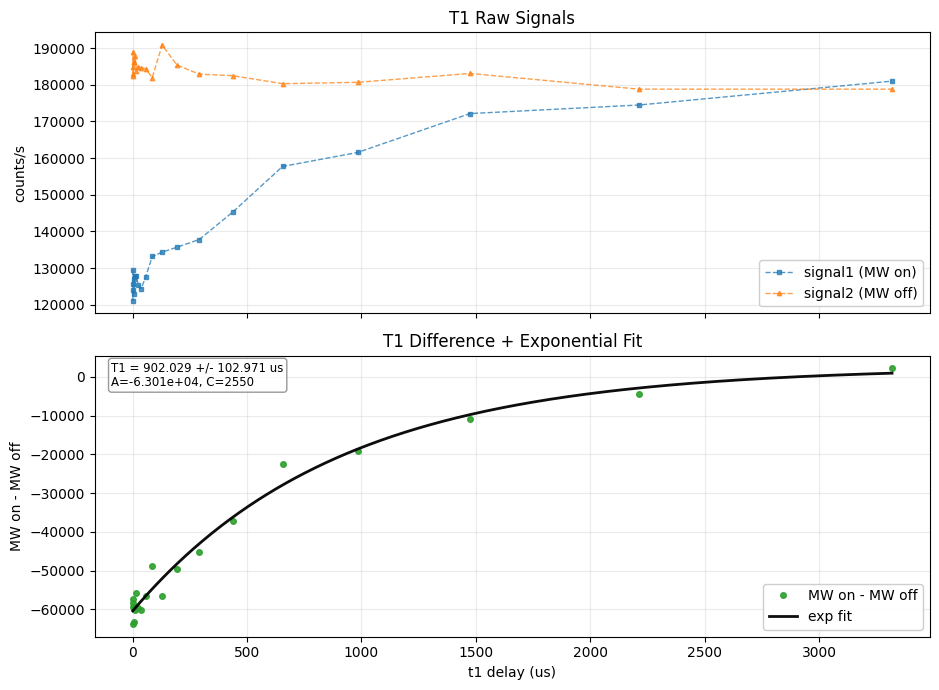

In [17]:
from pathlib import Path
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "jupyter_notebooks" else Path.cwd()

def collect_datasets(h5f):
    datasets = {}
    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            datasets[f"/{name}"] = np.asarray(obj[()])
    h5f.visititems(visitor)
    return datasets

def first_match(datasets, candidate_names):
    for candidate in candidate_names:
        for key, value in datasets.items():
            if Path(key).name == candidate:
                return np.asarray(value)
    return None

def exp_decay(x_us, amplitude, t1_us, offset):
    x_us = np.asarray(x_us, dtype=float)
    safe_t1 = np.clip(float(t1_us), 1e-9, None)
    return offset + amplitude * np.exp(-np.clip(x_us, 0.0, None) / safe_t1)

def fit_t1(x_us, y):
    x = np.asarray(x_us, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]

    if len(x) < 5:
        raise ValueError("Need at least 5 finite points to fit T1")

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    span = float(np.max(x) - np.min(x))
    if span <= 0:
        raise ValueError("Tau axis has zero span")

    y_lo, y_hi = float(np.min(y)), float(np.max(y))
    y_range = max(y_hi - y_lo, float(np.std(y)) * 2.0, 1e-6)

    p0 = [float(y[0] - y[-1]), max(span / 2.0, 1e-3), float(y[-1])]
    lower = [-5.0 * y_range, max(span / 500.0, 1e-3), y_lo - y_range]
    upper = [5.0 * y_range, max(span * 20.0, 10.0), y_hi + y_range]

    params, cov = curve_fit(
        exp_decay,
        x,
        y,
        p0=p0,
        bounds=(lower, upper),
        maxfev=60000,
    )

    sigma = np.sqrt(np.diag(cov)) if cov is not None else np.full(len(params), np.nan)
    fit_x = np.linspace(float(np.min(x)), float(np.max(x)), max(500, len(x) * 20))
    fit_y = exp_decay(fit_x, *params)

    return {
        "x": x,
        "y": y,
        "params": params,
        "sigma": sigma,
        "fit_x": fit_x,
        "fit_y": fit_y,
        "t1_us": float(params[1]),
        "t1_sigma_us": float(sigma[1]) if len(sigma) > 1 else np.nan,
    }

# Point this to your T1 file
# t1_file = Path(r"data\t1\t1_fine_res_20260324_180701.h5")
t1_file = Path(r"data\t1\t1_fine_res_20260324_170552.h5")
if not t1_file.is_absolute():
    t1_file = PROJECT_ROOT / t1_file

with h5py.File(t1_file, "r") as h5f:
    datasets = collect_datasets(h5f)

tau = first_match(datasets, ["t1_delay_tns", "tau_tns", "tau_ns", "tau_ftns", "tau_tus", "tau_us"])
signal_on = first_match(datasets, ["signal1_cts_s", "signal1"])
signal_off = first_match(datasets, ["signal2_cts_s", "signal2"])



if tau is None or signal_on is None or signal_off is None:
    raise KeyError("Missing one of required datasets: tau, signal1, signal2")

tau = np.asarray(tau, dtype=float).ravel()
signal_on = np.asarray(signal_on, dtype=float).ravel()
signal_off = np.asarray(signal_off, dtype=float).ravel()

# Convert tau to microseconds when needed
if np.nanmax(tau) > 1e4:
    tau_us = tau / 1e3
else:
    tau_us = tau

n = min(len(tau_us), len(signal_on), len(signal_off))
tau_us = tau_us[:n]
signal_on = signal_on[:n]
signal_off = signal_off[:n]

# Same observable used in your T1 processing style
diff_signal = signal_on - signal_off
fit = fit_t1(tau_us, diff_signal)

A, T1_us, C = fit["params"]
T1_sigma_us = fit["t1_sigma_us"]

print(f"File: {t1_file.name}")
print(f"Fit model: y = C + A * exp(-t/T1)")
print(f"A = {A:.6g}")
print(f"C = {C:.6g}")
if np.isfinite(T1_sigma_us):
    print(f"T1 = {T1_us:.3f} +/- {T1_sigma_us:.3f} us")
else:
    print(f"T1 = {T1_us:.3f} us (covariance unavailable)")

plt.close("all")
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(9.5, 7.0), sharex=True)

ax_top.plot(tau_us, signal_on, "s--", lw=1.0, ms=3.2, alpha=0.75, color="tab:blue", label="signal1 (MW on)")
ax_top.plot(tau_us, signal_off, "^--", lw=1.0, ms=3.2, alpha=0.75, color="tab:orange", label="signal2 (MW off)")
ax_top.set_ylabel("counts/s")
ax_top.set_title("T1 Raw Signals")
ax_top.grid(alpha=0.25)
ax_top.legend(loc="best", framealpha=0.95)

ax_bottom.plot(fit["x"], fit["y"], "o", markersize=4.0, alpha=0.9, color="tab:green", label="MW on - MW off")
ax_bottom.plot(fit["fit_x"], fit["fit_y"], "-", linewidth=2.0, color="black", alpha=0.95, label="exp fit")
ax_bottom.set_xlabel("t1 delay (us)")
ax_bottom.set_ylabel("MW on - MW off")
ax_bottom.set_title("T1 Difference + Exponential Fit")
ax_bottom.grid(alpha=0.25)
ax_bottom.legend(loc="best", framealpha=0.95)

if np.isfinite(T1_sigma_us):
    fit_text = f"T1 = {T1_us:.3f} +/- {T1_sigma_us:.3f} us"
else:
    fit_text = f"T1 = {T1_us:.3f} us"
model_text = f"A={A:.4g}, C={C:.4g}"
ax_bottom.text(
    0.02,
    0.98,
    f"{fit_text}\n{model_text}",
    transform=ax_bottom.transAxes,
    ha="left",
    va="top",
    fontsize=8.5,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, edgecolor="gray"),
)

plt.tight_layout()
plt.show()

File: t1_fine_res_combined (1).h5
Chunk count: 23
Reference filter: keep chunks with ref_level >= 36701.997
Mean ref_level=73403.994, min_ref_fraction=0.50
Dropped chunks: none

Per-chunk reference summary:
     chunk    ref1_mean    ref2_mean    ref_level  keep
chunk_0000 72092.816754 72127.664921 72110.240838  True
chunk_0001 72883.602094 73545.717277 73214.659686  True
chunk_0002 73400.963351 73848.628272 73624.795812  True
chunk_0003 73626.136126 74580.439791 74103.287958  True
chunk_0004 73781.612565 73805.738220 73793.675393  True
chunk_0005 74081.842932 73752.125654 73916.984293  True
chunk_0006 74081.842932 73114.136126 73597.989529  True
chunk_0007 74296.293194 73703.874346 74000.083770  True
chunk_0008 73376.837696 73647.581152 73512.209424  True
chunk_0009 73811.099476 74430.324607 74120.712042  True
chunk_0010 74588.481675 73492.104712 74040.293194  True
chunk_0011 74438.366492 74626.010471 74532.188482  True
chunk_0012 73904.921466 73207.958115 73556.439791  True
chunk_001

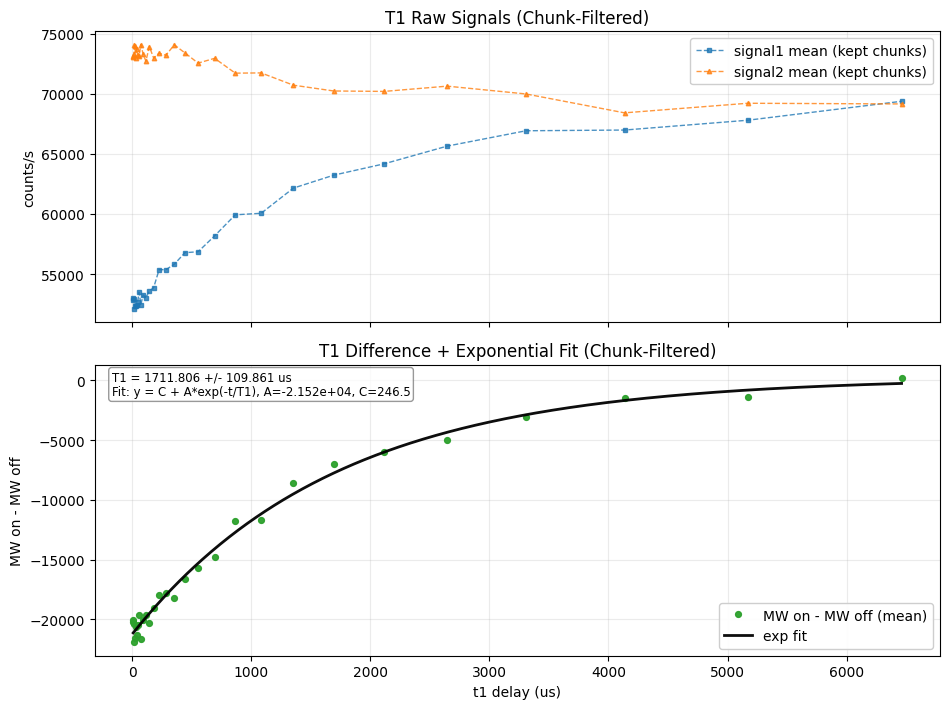

In [16]:
# T1 extraction with chunk-level reference filtering
from pathlib import Path
import re
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "jupyter_notebooks" else Path.cwd()

def _exp_decay_local(x_us_arr, amplitude, t1_us, offset):
    x_us_arr = np.asarray(x_us_arr, dtype=float)
    safe_t1 = np.clip(float(t1_us), 1e-9, None)
    return offset + amplitude * np.exp(-np.clip(x_us_arr, 0.0, None) / safe_t1)

def _fit_t1_local(x_us_arr, y):
    x_us_arr = np.asarray(x_us_arr, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)
    finite = np.isfinite(x_us_arr) & np.isfinite(y)
    x_us_arr = x_us_arr[finite]
    y = y[finite]
    if len(x_us_arr) < 5:
        return None
    order = np.argsort(x_us_arr)
    x_us_arr = x_us_arr[order]
    y = y[order]
    span = float(np.max(x_us_arr) - np.min(x_us_arr))
    if span <= 0:
        return None
    y_lo, y_hi = float(np.min(y)), float(np.max(y))
    y_range = max(y_hi - y_lo, float(np.std(y)) * 2.0, 1e-6)
    p0 = [float(y[0] - y[-1]), max(span / 2.0, 1e-3), float(y[-1])]
    bounds = (
        [-5.0 * y_range, max(span / 500.0, 1e-3), y_lo - y_range],
        [5.0 * y_range, max(span * 20.0, 10.0), y_hi + y_range],
    )
    try:
        params, cov = curve_fit(
            _exp_decay_local,
            x_us_arr,
            y,
            p0=p0,
            bounds=bounds,
            maxfev=60000,
        )
        fit_x = np.linspace(
            float(np.min(x_us_arr)),
            float(np.max(x_us_arr)),
            max(500, len(x_us_arr) * 20),
        )
        fit_sigma = np.sqrt(np.diag(cov)) if cov is not None else np.full(len(params), np.nan)
        return {
            "params": params,
            "fit_x": fit_x,
            "fit_y": _exp_decay_local(fit_x, *params),
            "t1_us": float(params[1]),
            "t1_sigma_us": float(fit_sigma[1]) if len(fit_sigma) > 1 else np.nan,
        }
    except (RuntimeError, ValueError):
        return None

def _read_first_dataset(data_group, names):
    for name in names:
        if name in data_group:
            return np.asarray(data_group[name][()])
    return None

def _chunk_numeric_key(name):
    m = re.search(r"(\d+)$", name)
    return int(m.group(1)) if m else 10**9

# Point this to your T1 file
t1_file = Path(r"data\t1_fine_res_combined (1).h5")
if not t1_file.is_absolute():
    t1_file = PROJECT_ROOT / t1_file

# Drop only very low-reference chunks: below half the global mean reference level
min_ref_fraction = 0.5

with h5py.File(t1_file, "r") as h5f:
    if "chunks" not in h5f:
        raise KeyError("Expected a /chunks group for chunk-level filtering")

    chunk_names = sorted(list(h5f["chunks"].keys()), key=_chunk_numeric_key)
    rows = []
    chunk_records = []

    for chunk_name in chunk_names:
        chunk_grp = h5f["chunks"][chunk_name]
        if "data" not in chunk_grp:
            continue
        data_grp = chunk_grp["data"]

        tau = _read_first_dataset(data_grp, ["t1_delay_tns", "tau_tns", "tau_ns", "tau_ftns", "tau_tus", "tau_us"])
        signal_on = _read_first_dataset(data_grp, ["signal1_cts_s", "signal1"])
        signal_off = _read_first_dataset(data_grp, ["signal2_cts_s", "signal2"])
        ref1 = _read_first_dataset(data_grp, ["reference1_cts_s", "reference1"])
        ref2 = _read_first_dataset(data_grp, ["reference2_cts_s", "reference2"])

        if tau is None or signal_on is None or signal_off is None or ref1 is None or ref2 is None:
            continue

        tau = np.asarray(tau, dtype=float).ravel()
        signal_on = np.asarray(signal_on, dtype=float).ravel()
        signal_off = np.asarray(signal_off, dtype=float).ravel()
        ref1 = np.asarray(ref1, dtype=float).ravel()
        ref2 = np.asarray(ref2, dtype=float).ravel()

        n = min(len(tau), len(signal_on), len(signal_off), len(ref1), len(ref2))
        tau = tau[:n]
        signal_on = signal_on[:n]
        signal_off = signal_off[:n]
        ref1 = ref1[:n]
        ref2 = ref2[:n]

        tau_us = tau / 1e3 if np.nanmax(tau) > 1e4 else tau

        ref_level = float(np.nanmean(np.r_[ref1, ref2]))
        rows.append({
            "chunk": chunk_name,
            "ref1_mean": float(np.nanmean(ref1)),
            "ref2_mean": float(np.nanmean(ref2)),
            "ref_level": ref_level,
        })

        chunk_records.append({
            "chunk": chunk_name,
            "tau_us": tau_us,
            "signal_on": signal_on,
            "signal_off": signal_off,
            "ref1": ref1,
            "ref2": ref2,
            "ref_level": ref_level,
        })

if not chunk_records:
    raise RuntimeError("No valid chunks with tau/signal/reference datasets were found")

quality_df = pd.DataFrame(rows).sort_values("chunk").reset_index(drop=True)
ref_levels = quality_df["ref_level"].to_numpy(dtype=float)
ref_mean = float(np.mean(ref_levels))
cutoff = min_ref_fraction * ref_mean
quality_df["keep"] = quality_df["ref_level"] >= cutoff

keep_chunks = set(quality_df.loc[quality_df["keep"], "chunk"].tolist())
drop_chunks = quality_df.loc[~quality_df["keep"], "chunk"].tolist()

print(f"File: {t1_file.name}")
print(f"Chunk count: {len(quality_df)}")
print(f"Reference filter: keep chunks with ref_level >= {cutoff:.3f}")
print(f"Mean ref_level={ref_mean:.3f}, min_ref_fraction={min_ref_fraction:.2f}")
if drop_chunks:
    print(f"Dropped chunks: {drop_chunks}")
else:
    print("Dropped chunks: none")

display_cols = ["chunk", "ref1_mean", "ref2_mean", "ref_level", "keep"]
print("\nPer-chunk reference summary:")
print(quality_df[display_cols].to_string(index=False))

kept_records = [r for r in chunk_records if r["chunk"] in keep_chunks]
if not kept_records:
    raise RuntimeError("All chunks were excluded. Lower min_ref_fraction or inspect data quality.")

# Aggregate by simple averaging across kept chunks
tau_us = kept_records[0]["tau_us"]
signal_on_stack = np.vstack([r["signal_on"] for r in kept_records])
signal_off_stack = np.vstack([r["signal_off"] for r in kept_records])

signal_on = np.nanmean(signal_on_stack, axis=0)
signal_off = np.nanmean(signal_off_stack, axis=0)
diff_signal = signal_on - signal_off

fit = _fit_t1_local(tau_us, diff_signal)
if fit is None:
    raise RuntimeError("T1 fit did not converge after chunk filtering")

amp = float(fit["params"][0])
t1_us = float(fit["t1_us"])
t1_sigma_us = float(fit["t1_sigma_us"])
offset = float(fit["params"][2])

print(f"\nKept chunks: {len(kept_records)} / {len(chunk_records)}")
print(f"[t1] Filtered fit: A={amp:.6g}, T1={t1_us:.3f} us, C={offset:.6g}")
if np.isfinite(t1_sigma_us):
    print(f"T1 = {t1_us:.3f} +/- {t1_sigma_us:.3f} us")
else:
    print(f"T1 = {t1_us:.3f} us")

plt.close("all")
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(9.6, 7.2), sharex=True)
ax_top.plot(tau_us, signal_on, "s--", lw=1.0, ms=3.2, alpha=0.8, color="tab:blue", label="signal1 mean (kept chunks)")
ax_top.plot(tau_us, signal_off, "^--", lw=1.0, ms=3.2, alpha=0.8, color="tab:orange", label="signal2 mean (kept chunks)")
ax_top.set_ylabel("counts/s")
ax_top.set_title("T1 Raw Signals (Chunk-Filtered)")
ax_top.grid(alpha=0.25)
ax_top.legend(loc="best", framealpha=0.95)

ax_bottom.plot(tau_us, diff_signal, "o", markersize=4.2, alpha=0.95, color="tab:green", label="MW on - MW off (mean)")
ax_bottom.plot(fit["fit_x"], fit["fit_y"], "-", linewidth=2.0, color="black", alpha=0.95, label="exp fit")
ax_bottom.set_xlabel("t1 delay (us)")
ax_bottom.set_ylabel("MW on - MW off")
ax_bottom.set_title("T1 Difference + Exponential Fit (Chunk-Filtered)")
ax_bottom.grid(alpha=0.25)
ax_bottom.legend(loc="best", framealpha=0.95)

fit_text = f"T1 = {t1_us:.3f} +/- {t1_sigma_us:.3f} us" if np.isfinite(t1_sigma_us) else f"T1 = {t1_us:.3f} us"
fit_model_text = f"Fit: y = C + A*exp(-t/T1), A={amp:.4g}, C={offset:.4g}"
ax_bottom.text(
    0.02,
    0.98,
    f"{fit_text}\n{fit_model_text}",
    transform=ax_bottom.transAxes,
    ha="left",
    va="top",
    fontsize=8.5,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, edgecolor="gray"),
)

plt.tight_layout()
plt.show()

In [14]:
from pathlib import Path
import numpy as np
import h5py

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "jupyter_notebooks" else Path.cwd()
t1_file = Path(r"data\t1_fine_res_combined (1).h5")
if not t1_file.is_absolute():
    t1_file = PROJECT_ROOT / t1_file

candidates = [
    "t1_delay_tns", "tau_tns", "tau_ns", "tau_ftns", "tau_tus", "tau_us",
    "signal1_cts_s", "signal1", "signal2_cts_s", "signal2",
    "reference1_cts_s", "reference1", "reference2_cts_s", "reference2",
    "chunk", "chunk_id", "chunk_idx", "reps", "rep",
    "signal1_chunks", "signal2_chunks", "reference1_chunks", "reference2_chunks",
]

with h5py.File(t1_file, "r") as h5f:
    found = {}
    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            leaf = Path(name).name
            if leaf in candidates and leaf not in found:
                arr = np.asarray(obj[()])
                found[leaf] = (f"/{name}", arr.shape, arr.dtype)
    h5f.visititems(visitor)

print(f"Inspecting exact candidate datasets in: {t1_file.name}")
for k in candidates:
    if k in found:
        p, shp, dt = found[k]
        print(f"{k:18s} -> {p:45s} shape={shp} dtype={dt}")

Inspecting exact candidate datasets in: t1_fine_res_combined (1).h5
t1_delay_tns       -> /chunks/chunk_0000/data/t1_delay_tns          shape=(30,) dtype=float64
signal1_cts_s      -> /chunks/chunk_0000/data/signal1_cts_s         shape=(30,) dtype=float64
signal1            -> /chunks/chunk_0000/data/signal1               shape=(30,) dtype=int64
signal2_cts_s      -> /chunks/chunk_0000/data/signal2_cts_s         shape=(30,) dtype=float64
signal2            -> /chunks/chunk_0000/data/signal2               shape=(30,) dtype=int64
reference1_cts_s   -> /chunks/chunk_0000/data/reference1_cts_s      shape=(30,) dtype=float64
reference1         -> /chunks/chunk_0000/data/reference1            shape=(30,) dtype=int64
reference2_cts_s   -> /chunks/chunk_0000/data/reference2_cts_s      shape=(30,) dtype=float64
reference2         -> /chunks/chunk_0000/data/reference2            shape=(30,) dtype=int64
